### Degree in Data Science and Engineering, group 96
### Machine Learning in Healthcare - Fall 2025

&nbsp;
# Lab 3. Multi-View VAE
&nbsp;

Enica King (100496551@alumnos.uc3m.es)

Jingyi Fu (100576636@alumnos.uc3m.es)

## Loading packages and files



In [2]:
import pandas as pd
import numpy as np
import random
import torch
from torchvision import datasets, transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import io, zipfile
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

## Constructing MNIST-SVHN

In [190]:
!pip install torch torchvision

In [191]:
# Define a transform to convert the data to tensor
transform = transforms.ToTensor()

# Load MNIST
train_dataset_mnist = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset_mnist = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Load SVHN
train_dataset_svhn = datasets.SVHN(root='data', split='train', download=True, transform=transform)
test_dataset_svhn = datasets.SVHN(root='data', split='test', download=True, transform=transform)

In [192]:
# Pair each MNIST sample with a random SVHN sample of the same digit by index
def build_label_index(dataset, is_mnist=True):
    buckets = {i: [] for i in range(10)}
    if is_mnist:
        for i in range(len(dataset)):
            _, y = dataset[i]
            buckets[int(y)].append(i)
    else:
        # SVHN labels: dataset.labels as ndarray; '10' stands for '0' in original SVHN,
        labels = dataset.labels if isinstance(dataset.labels, np.ndarray) else np.array(dataset.labels)
        labels = labels.astype(int)
        labels = np.where(labels == 10, 0, labels)
        for i, y in enumerate(labels):
            buckets[int(y)].append(i)
    return buckets

mnist_idx = build_label_index(train_dataset_mnist, is_mnist=True)
svhn_idx  = build_label_index(train_dataset_svhn,  is_mnist=False)

pairs = []
for d in range(10):
    m_list = mnist_idx[d][:]
    s_list = svhn_idx[d][:]
    random.shuffle(m_list)
    random.shuffle(s_list)
    n = min(len(m_list), len(s_list))
    pairs.extend([(m_list[i], s_list[i], d) for i in range(n)])
random.shuffle(pairs)
print("Total paired samples:", len(pairs))

class PairedMNISTSVHN(Dataset):
    def __init__(self, mnist_ds, svhn_ds, pairs):
        self.mnist = mnist_ds
        self.svhn  = svhn_ds
        self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        mi, si, lab = self.pairs[idx]
        x_m, y_m = self.mnist[mi]
        x_s, _   = self.svhn[si]
        # labels agree by construction; we return both images + label
        return x_m, x_s, lab

train_paired = PairedMNISTSVHN(train_dataset_mnist, train_dataset_svhn, pairs)
train_loader = DataLoader(train_paired, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

# For evaluation, we’ll just take a small paired set from the test splits similarly:
test_mnist_idx = build_label_index(test_dataset_mnist, is_mnist=True)
test_svhn_idx  = build_label_index(test_dataset_svhn,  is_mnist=False)
test_pairs = []
# pair MNIST and SVHN samples with the same label for each digit (0-9)
for d in range(10):
    m_list = test_mnist_idx[d][:]
    s_list = test_svhn_idx[d][:]
    random.shuffle(m_list); random.shuffle(s_list) # shuffle to get random pairings
    n = min(len(m_list), len(s_list), 512)
    test_pairs.extend([(m_list[i], s_list[i], d) for i in range(n)])
test_paired = PairedMNISTSVHN(test_dataset_mnist, test_dataset_svhn, test_pairs)

# create a dataset loader for training purposes
test_loader = DataLoader(test_paired, batch_size=128, shuffle=False, num_workers=2, drop_last=False)


Total paired samples: 56068


In [193]:
train_paired[56000][1].shape

torch.Size([3, 32, 32])

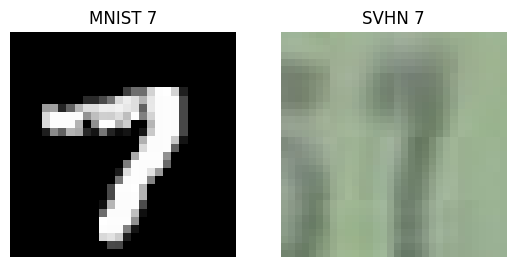

In [194]:
x_m, x_s, lab = train_paired[81]
plt.subplot(1,2,1)
plt.imshow(x_m.squeeze(), cmap='gray')
plt.title(f"MNIST {lab}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(x_s.permute(1,2,0))
plt.title(f"SVHN {lab}")
plt.axis('off')
plt.show()

## Multi-view VAE: Encoder-Decoder
### MNIST Encoder-Decoder

In [195]:
class MNIST_encoder(nn.Module):
    '''This class corresponds to MNIST encoder. It receives as imput the dimension of the latent space.
    In this case, the number of entering channels is only one because MNIST dataset is composed of gray-scale images'''


    def __init__(self,dimz,channels=1,var_x=0.1):
        super().__init__()
        self.dimz = dimz    #dimz is k, the dimension of the latent space

        # Output Size Formula: [(W−K+2P)/S]+1
        #W = Width/Length of the image
        #K = Filter Kernel Size
        #P = Padding(Extra-Pixels in borders, normally 0s)
        #S = Stride(Steps the Kernel moves)

        #Input dim: [32, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=channels, out_channels=14,
                               kernel_size=4, stride=2, padding=1)

        #Output dim: [32, 14, 14, 14]
        self.conv2 = nn.Conv2d(in_channels=14, out_channels=28,
                               kernel_size=4, stride=2, padding=2)

        #Output dim: [32, 28, 8, 8]
        self.conv3 = nn.Conv2d(in_channels=28, out_channels=56,
                               kernel_size=4, stride=2, padding=1)

        #Output dim: [32, 56, 4, 4]
        self.conv4 = nn.Conv2d(in_channels=56, out_channels=112,
                               kernel_size=4, stride=1, padding=0)

        #Output dim: [32, 112, 1, 1]

        # self.linear is a linear layer with dimz*2 outputs
        self.linear = nn.Linear(112,dimz*2)

        self.relu = nn.ReLU()

        self.softplus = nn.Softplus()

    def forward(self,x):

        z = self.relu(self.conv1(x))
        z = self.relu(self.conv2(z))
        z = self.relu(self.conv3(z))
        z = self.relu(self.conv4(z))

        # Transform z into a 256-dim vector
        z = z.view(-1,112)
        z = self.linear(z)

        return z

    def encode_and_sample(self,x,flag_sample=True):
        z = self.forward(x)
        mu = z[:, :self.dimz]
        var = self.softplus(0.5 * z[:, self.dimz:])
        sample = None

        if(flag_sample==True):
            eps = torch.randn_like(var)
            sample = mu + eps*(var**0.5)

        return mu,var,sample

In [196]:
mnist_enc = MNIST_encoder(dimz=10)

# i,l = train_dataset_mnist[0]

x_m, x_s, lab = train_paired[0]
i = x_m
# i

mu_z,var_z,sample = mnist_enc.encode_and_sample(i)

print(mu_z[0,:])
print(var_z[0,:])

tensor([-0.0089, -0.0285, -0.0489,  0.0488,  0.0467, -0.0545,  0.0169, -0.0718,
         0.0498,  0.0298], grad_fn=<SelectBackward0>)
tensor([0.7031, 0.6749, 0.7156, 0.7153, 0.6733, 0.6907, 0.6831, 0.7000, 0.6980,
        0.7135], grad_fn=<SelectBackward0>)


In [197]:


class MNIST_decoder(nn.Module):

    def __init__(self,dimz,channels=1,var_x=0.1):
        super().__init__()

        self.linear = nn.Linear(dimz,112)

        self.tconv1 = nn.ConvTranspose2d(112, 56, kernel_size=4, stride=1,padding=0)
        self.tconv2 = nn.ConvTranspose2d(56, 28, kernel_size=4, stride=2,padding=1)
        self.tconv3 = nn.ConvTranspose2d(28, 14, kernel_size=4, stride=2,padding=2)
        self.tconv4 = nn.ConvTranspose2d(14, channels, kernel_size=4, stride=2,padding=1)

        self.relu = nn.ReLU()

        self.tanh = nn.Tanh()

    def forward(self,z):

        x = self.relu(self.linear(z).view(-1,112,1,1))
        x = self.relu(self.tconv1(x))
        x = self.relu(self.tconv2(x))
        x = self.relu(self.tconv3(x))
        x = self.relu(self.tconv4(x))
        return x

    def decode(self,z):

        return self.forward(z)



In [198]:
def imshow(img):
    img = img / 2 + 0.5      # unnormalize
    npimg = img.numpy()

    # case 1: (H, W)
    if npimg.ndim == 2:
        plt.imshow(npimg, cmap='gray')
    # case 2: (1, H, W)
    elif npimg.shape[0] == 1:
        plt.imshow(npimg[0], cmap='gray')
    # case 3: (3, H, W)
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

    plt.axis('off')
    plt.show()


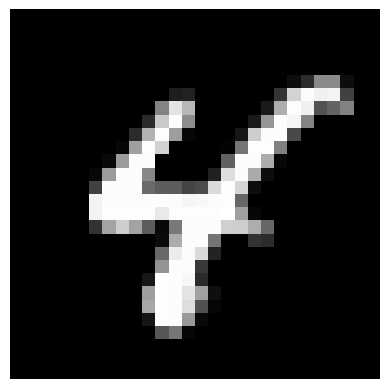

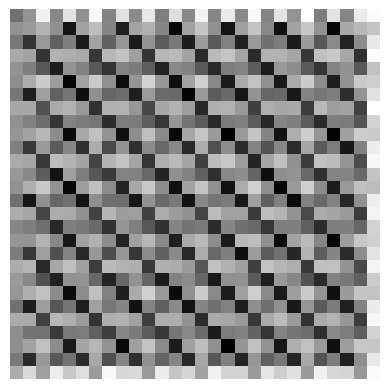

In [199]:
mnist_dec = MNIST_decoder(dimz=10)

i,l = train_dataset_mnist[0]
x_m, x_s, lab = train_paired[0]
i = x_m

mu_z,var_z,sample = mnist_enc.encode_and_sample(i)

x_mean = mnist_dec.decode(mu_z).detach()
imshow(i[0,:,:])
imshow(x_mean[0,:,:,:])

### SVHN Encoder-Decoder

In [200]:
class SVHN_encoder(nn.Module):
    '''This class corresponds to SVHM encoder. It receives as imput the dimension of the latent space.
    In this case, the number of entering channels is only one because SVHM dataset is composed of gray-scale images'''

    def __init__(self,dimz,channels=3,var_x=0.1):

        super().__init__()

        self.dimz = dimz    #dimz is k, the dimension of the latent space

        # Output Size Formula: [(W−K+2P)/S]+1
        #W = Width/Length of the image
        #K = Filter Kernel Size
        #P = Padding(Extra-Pixels in borders, normally 0s)
        #S = Stride(Steps the Kernel moves)

        #Input dim: [32, 3, 64, 64]
        self.conv1 = nn.Conv2d(in_channels=channels, out_channels=32,
                               kernel_size=4, stride=2, padding=1)

        #Output dim: [32, 32, 32, 32]
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32,
                               kernel_size=4, stride=2, padding=1)

        #Output dim: [32, 32, 16, 16]
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=4, stride=2, padding=1)

        #Output dim: [32, 64, 8, 8]
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64,
                               kernel_size=4, stride=2, padding=1)

        #Output dim: [32, 64, 4, 4]
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=256,
                               kernel_size=4, stride=1, padding=1)

        #Output dim: [32, 256, 1, 1]

        # self.linear is a linear layer with dimz*2 outputs
        self.linear = nn.Linear(256,dimz*2)

        self.relu = nn.ReLU()

        self.softplus = nn.Softplus()

    def forward(self,x):
        z = self.relu(self.conv1(x))
        z = self.relu(self.conv2(z))
        z = self.relu(self.conv3(z))
        z = self.relu(self.conv4(z))
        z = self.relu(self.conv5(z))

        # Transform z into a 256-dim vector
        z = z.view(-1,256)
        z = self.linear(z)

        return z

    def encode_and_sample(self,x,flag_sample=True):

        z = self.forward(x)
        mu = z[:, :self.dimz]
        var = self.softplus(0.5 * z[:, self.dimz:])

        sample = None

        if(flag_sample==True):
            eps = torch.randn_like(var)
            sample = mu + eps*(var**0.5)

        return mu,var,sample

In [201]:
svhn_enc = SVHN_encoder(dimz=10) #10 numbers (0 to 9)

i,l = train_dataset_svhn[5]

mu_z,var_z,sample = svhn_enc.encode_and_sample(i)

print(mu_z[0,:])
print(var_z[0,:])

tensor([ 0.0213,  0.0232, -0.0167, -0.0117, -0.0480, -0.0203, -0.0242,  0.0110,
         0.0519, -0.0122], grad_fn=<SelectBackward0>)
tensor([0.6969, 0.6968, 0.6875, 0.7043, 0.7063, 0.7115, 0.6865, 0.7021, 0.6915,
        0.6993], grad_fn=<SelectBackward0>)


In [202]:
class SVHN_decoder(nn.Module):

    def __init__(self,dimz,channels=3,var_x=0.1):
        super().__init__()
        self.linear = nn.Linear(dimz,256)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

        # self.tconv1 is a convolutional layer, with 64 output channels, kernel size 4, stride 1,
        # and padding 0
        self.tconv1 = nn.ConvTranspose2d(256, 64, kernel_size=4, stride=1,padding=0)

        # self.tconv2 is a convolutional layer, with 64 output channels, kernel size 4, stride 2,
        # and padding 1
        self.tconv2 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2,padding=1)

        # self.tconv3 is a convolutional layer, with 32 output channels, kernel size 4, stride 2,
        # and padding 1
        self.tconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2,padding=1)

        # self.tconv3 is a convolutional layer, with 32 output channels, kernel size 4, stride 2,
        # and padding 1
        self.tconv4 = nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1)

        # self.tconv3 is a convolutional layer, with channels output channels, kernel size 4, stride 2,
        # and padding 1
        # self.tconv5 = nn.ConvTranspose2d(32, channels, kernel_size=4, stride=2,padding=1)
        # final conv that keeps 32×32
        self.tconv5 = nn.Conv2d(32, channels, kernel_size=3, padding=1)

    def forward(self,z):
        x = self.relu(self.linear(z).view(-1,256,1,1))
        x = self.relu(self.tconv1(x)) # 4x4
        x = self.relu(self.tconv2(x)) # 8x8
        x = self.relu(self.tconv3(x)) # 16x16
        x = self.relu(self.tconv4(x)) # 32x32
        x = self.tanh(self.tconv5(x)) # keeps 32x32, expands into 3 channels
        return x

    def decode(self,z):
        return self.forward(z)

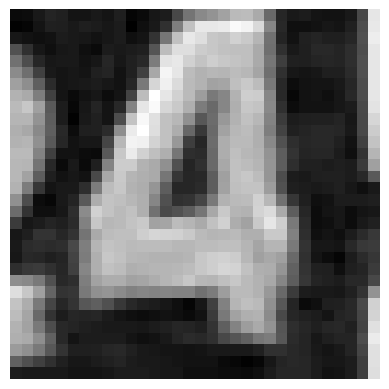

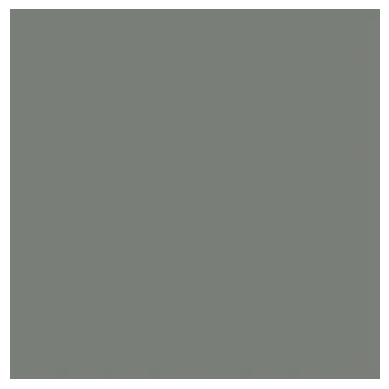

In [203]:
# use case
svhn_dec = SVHN_decoder(dimz=10)

x_m, x_s, lab = train_paired[0]
i = x_s

mu_z,var_z,sample = svhn_enc.encode_and_sample(i)
x_mean = svhn_dec.decode(mu_z).detach()

imshow(i[0,:,:])
imshow(x_mean[0,:,:,:])

##Loss Function

In [204]:
def eval_Gaussian_LL(x,mu_x,var_x):

    # x is a mini-batch of images.

    # mu_x is a mini-batch of reconstructed images.

    # var_x is a torch constant

    D = x.shape[1] * x.shape[2] * x.shape[3]   # Dimension
    x = x.reshape(-1, D)
    mu_x = mu_x.reshape(-1, D)
    var_x = torch.ones_like(mu_x) * var_x

    cnt = D * np.log(2 * np.pi) + torch.sum(torch.log(var_x), dim=-1)
    logp_data = -0.5 * (cnt + torch.sum((x - mu_x) * var_x ** -1 * (x - mu_x), dim=-1))
    logp = torch.sum(logp_data)

    return logp,logp_data


MNIST total logp: -301.55010986328125   per-image logp_data shape: torch.Size([1])
SVHN  total logp: -6740.12158203125   per-image logp_data shape: torch.Size([1])


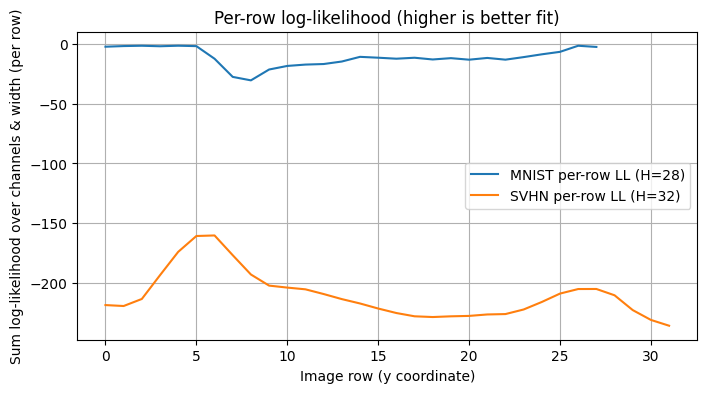

In [205]:

# constants
var_x = 0.1
two_pi = 2.0 * np.pi

x_m, x_s, lab = train_paired[1]
# --- get samples and ensure batch dimension ---
MNIST_i = x_m  # MNIST_i shape: (1,28,28)
SVHN_i  = x_s   # SVHN_i  shape: (3,32,32)

MNIST_x_b = MNIST_i.unsqueeze(0)
SVHN_x_b  = SVHN_i.unsqueeze(0)

# --- encode (make sure your encoders accept batched inputs) ---
MNIST_mu_z, MNIST_var_z, MNIST_sample = mnist_enc.encode_and_sample(MNIST_x_b)
SVHN_mu_z,  SVHN_var_z,  SVHN_sample  = svhn_enc.encode_and_sample(SVHN_x_b)

# --- Product-of-Experts (simple average you used) ---
mu_z = 0.5 * MNIST_mu_z + 0.5 * SVHN_mu_z
var_z = 0.5 * MNIST_var_z + 0.5 * SVHN_var_z

# --- decode (batched) -> decoder outputs should be (1,C,H,W) ---
MNIST_x_mean = mnist_dec.decode(mu_z).detach()  # expected (1,1,28,28)
SVHN_x_mean  = svhn_dec.decode(mu_z).detach()   # expected (1,3,32,32)

# --- call the provided eval_Gaussian_LL (keeps contract) ---
MNIST_logp, MNIST_logp_data = eval_Gaussian_LL(
    x=MNIST_x_b,
    mu_x=MNIST_x_mean,
    var_x=var_x
)
SVHN_logp, SVHN_logp_data = eval_Gaussian_LL(
    x=SVHN_x_b,
    mu_x=SVHN_x_mean,
    var_x=var_x
)

print("MNIST total logp:", MNIST_logp.item(), "  per-image logp_data shape:", MNIST_logp_data.shape)
print("SVHN  total logp:", SVHN_logp.item(),  "  per-image logp_data shape:", SVHN_logp_data.shape)

# --- compute per-pixel log-likelihood contributions
# per_pixel_ll has shape (batch, C, H, W)
with torch.no_grad():
    log_term = np.log(two_pi * var_x)
    MNIST_sq = (MNIST_x_b - MNIST_x_mean).pow(2)
    SVHN_sq  = (SVHN_x_b  - SVHN_x_mean).pow(2)

    MNIST_per_pixel = -0.5 * (log_term + (MNIST_sq / var_x))
    SVHN_per_pixel  = -0.5 * (log_term + (SVHN_sq  / var_x))

    # shapes check
    # MNIST_per_pixel -> (1, 1, 28, 28)
    # SVHN_per_pixel  -> (1, 3, 32, 32)

    # collapse to per-row: sum over channels and width -> length = H
    MNIST_per_row = MNIST_per_pixel.squeeze(0).sum(dim=0).sum(dim=-1)  # (H,)
    SVHN_per_row  = SVHN_per_pixel.squeeze(0).sum(dim=0).sum(dim=-1)   # (H,)

    # convert to numpy for plotting
    mnist_row = MNIST_per_row.cpu().numpy()
    svhn_row  = SVHN_per_row.cpu().numpy()

    # heights
    H_m = mnist_row.shape[0]   # should be 28
    H_s = svhn_row.shape[0]    # should be 32

# --- Plot per-row log-likelihoods (meaningful, comparable summary) ---
plt.figure(figsize=(8,4))
plt.plot(np.arange(H_m), mnist_row, label=f'MNIST per-row LL (H={H_m})')
plt.plot(np.arange(H_s), svhn_row,  label=f'SVHN per-row LL (H={H_s})')
plt.xlabel('Image row (y coordinate)')
plt.ylabel('Sum log-likelihood over channels & width (per row)')
plt.title('Per-row log-likelihood (higher is better fit)')
plt.legend()
plt.grid(True)
plt.show()

##Projection into the shared latent space

In [222]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiViewLatent(nn.Module):

    def __init__(self, enc_m, enc_s):
        super().__init__()
        self.enc_m = enc_m
        self.enc_s = enc_s

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # Product of Experts fusion
    def projection(self, mu_list, logvar_list, eps=1e-8):
        # precision = 1 / variance = exp(-logvar)
        precisions = [torch.exp(-lv) for lv in logvar_list]

        precision_sum = torch.stack(precisions).sum(dim=0) + eps
        weighted_mu = torch.stack([m * p for m, p in zip(mu_list, precisions)]).sum(dim=0)

        mu_fused = weighted_mu / precision_sum
        logvar_fused = -torch.log(precision_sum + eps)

        logvar_fused = torch.clamp(logvar_fused, min=-10)
        return mu_fused, logvar_fused

    # Fusion of MNIST + SVHN
    def mutual(self, x_m, x_s):
        # encoders return (mu, var, sample)
        mu_m, var_m, _ = self.enc_m.encode_and_sample(x_m)
        mu_s, var_s, _ = self.enc_s.encode_and_sample(x_s)

        # convert var → logvar
        logvar_m = torch.log(var_m + 1e-8)
        logvar_s = torch.log(var_s + 1e-8)

        # PoE fusion
        mu_joint, logvar_joint = self.projection(
            [mu_m, mu_s],
            [logvar_m, logvar_s]
        )

        return mu_joint, logvar_joint, (mu_m, logvar_m, mu_s, logvar_s)

    # sample z ~ q(z | x_m, x_s)
    def sample_joint(self, x_m, x_s):
        mu_joint, logvar_joint, extra = self.mutual(x_m, x_s)
        z = self.reparameterize(mu_joint, logvar_joint)
        return z, mu_joint, logvar_joint, extra

    def plot_projection(latent_module, loader, device, max_batches=1):
      latent_module.eval()
      mus = []
      with torch.no_grad():
          for i, (x_m, x_s, y) in enumerate(loader):
              x_m = x_m.to(device)
              x_s = x_s.to(device)
              mu_joint, logvar_joint, _ = latent_module.mutual(x_m, x_s)
              mus.append(mu_joint.detach().cpu().numpy())

              if i + 1 >= max_batches:
                  break

      Z = np.concatenate(mus, axis=0)

      plt.figure(figsize=(8, 5))
      plt.plot(Z[:, 0], label="z[0]")
      plt.plot(Z[:, 1], label="z[1]")
      plt.title("Projection Test (First 2 Latent Dimensions)")
      plt.xlabel("Sample Index")
      plt.ylabel("Latent Value")
      plt.legend()
      plt.grid(True)
      plt.show()


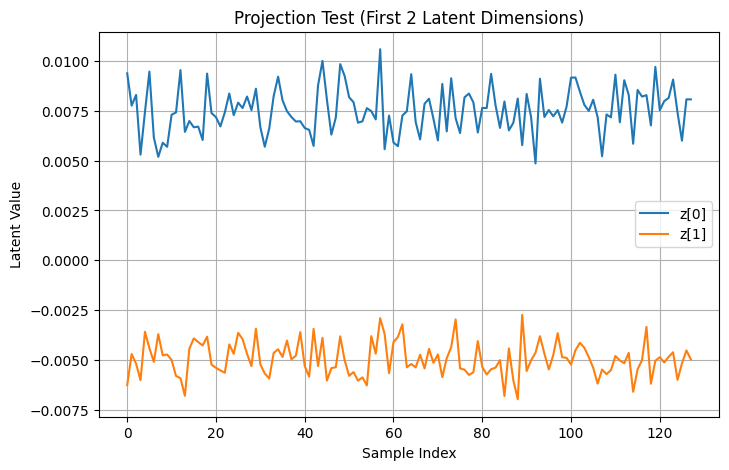

In [223]:
latent_mod = MultiViewLatent(enc_m=mnist_enc, enc_s=svhn_enc)
MultiViewLatent.plot_projection(latent_mod, test_loader, device)

## Reconstruction, generation from latent space, and cross-domain generation

In [ ]:
class MultiViewVAE(nn.Module):
    def __init__(self, latent_module, mnist_dec, svhn_dec):
        super().__init__()
        self.latent_module = latent_module
        self.mnist_dec = mnist_dec
        self.svhn_dec = svhn_dec

    def forward(self, x_m, x_s):
        z, mu_z, logvar_z, extra = self.latent_module.sample_joint(x_m, x_s)
        x_m_hat = self.mnist_dec.decode(z)
        x_s_hat = self.svhn_dec.decode(z)
        return x_m_hat, x_s_hat, z, mu_z, logvar_z, extra


In [ ]:

# ---- MultiViewVAE wrapper ----
class TrainableMultiViewVAE(nn.Module):
    def __init__(self, model, var_x=0.1):
        super().__init__()
        self.model = model
        self.var_x = var_x

    def compute_loss(self, x_m, x_s):
        x_m_hat, x_s_hat, z, mu_z, logvar_z, (mu_m, logvar_m, mu_s, logvar_s) = self.model(x_m, x_s)
        mnist_logp, _ = eval_Gaussian_LL(x_m, x_m_hat, self.var_x)
        svhn_logp, _  = eval_Gaussian_LL(x_s, x_s_hat, self.var_x)
        recon = (mnist_logp + svhn_logp) / x_m.size(0)
        var_z = torch.exp(logvar_z)
        kl = 0.5 * torch.sum(mu_z**2 + var_z - 1 - logvar_z, dim=1).mean()

        loss = -(recon - kl)

        return loss, {
            "recon": recon.item(),
            "kl": kl.item(),
            "elbo": (recon-kl).item()
        }

In [ ]:
# ---- Example: sample and visualize reconstructions after training ----
model.eval()
with torch.no_grad():
    # get one batch from test loader
    for batch in test_loader:
        x_m, x_s, _ = batch
        x_m = x_m.to(device); x_s = x_s.to(device)
        x_m_mean, x_s_mean, _, _, _ = model.forward(x_m, x_s)
        break

# Move to cpu and visualize first example (use your imshow that handles shapes)
orig_m = x_m[0].cpu()
recon_m = x_m_mean[0].cpu()
orig_s = x_s[0].cpu()
recon_s = x_s_mean[0].cpu()

imshow(orig_m)
imshow(recon_m)
imshow(orig_s)
imshow(recon_s)

## Visualize the latent space through the t-SNE method


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

class Visualizer:
    """
    Visualize the shared latent space learned by the Multi-View VAE
    using t-SNE dimensionality reduction
    """

    def __init__(self, latent_module, device="cpu"):
        self.latent_module = latent_module
        self.device = device


    def extract_latent(self, loader, max_batches=None):
        self.latent_module.eval()
        Z = []
        Y = []
        with torch.no_grad():
            for i, (x_m, x_s, y) in enumerate(loader):
                x_m = x_m.to(self.device)
                x_s = x_s.to(self.device)

                mu_joint, _, _ = self.latent_module.mutual(x_m, x_s)
                Z.append(mu_joint.cpu())
                Y.append(y)

                if max_batches and i + 1 >= max_batches:
                    break

        return torch.cat(Z).numpy(), torch.cat(Y).numpy()



    def plot_tsne(self, Z, y, title="t-SNE of Shared Latent Space"):
        print("Running t-SNE")
        tsne = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate=200,
            init="random",
            random_state=0
        )
        Z2 = tsne.fit_transform(Z)

        # Plot
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(Z2[:, 0], Z2[:, 1], c=y, cmap="tab10", s=5)
        cbar = plt.colorbar(scatter, ticks=range(10))
        cbar.set_label("Digit Label")
        plt.title(title)
        plt.xlabel("t-SNE dim 1")
        plt.ylabel("t-SNE dim 2")
        plt.tight_layout()
        plt.show()


    def run(self, test_loader, max_batches=None):
        Z, y = self.extract_latent(test_loader, max_batches=max_batches)
        self.plot_tsne(Z, y)
